for a stellar atmosphere of pure He, find the temperature at the middle of the HeI partial ionizatoin zone, where half of HeI atoms are ionized

Saha eqn: $(N_{i+1}/N_i) =  \frac{2 k T Z_{i+1}}{P_e Z_i}  \left( \frac{2\pi m_e k T}{h^2} \right)^{3/2} e^{-\chi_i/kT}$

Also, in part $(b)$ we found $N_{II}/N_t = \frac{N_{II}/N_I}{1+ N_{II}/N_I + N_{III}/N_{II} N_{II}/N_I}$

In [ ]:
import astropy.constants as c
import astropy.units as u
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


###  given constants
X = [24.6, 54.4]*u.eV
Z = [1, 2, 1]
# P_e = n_e*k*T
P_e = 20*u.N/u.m**2

# saha equation for given parameters
def saha(i, X, Z, P_e, T):
    return (2*c.k_B*T*Z[i+1]/P_e/Z[i]) * (2*np.pi*c.m_e*c.k_B*T/c.h**2)**(3/2) * np.exp(-X[i]/c.k_B/T)


In [ ]:
# a) find N_II/N_I and N_III/N_II for a series of temperatures

T = np.linspace(5000, 25000, 3)*u.K
N_2_over_N_1 = saha(0, X, Z, P_e, T)
N_3_over_N_2 = saha(1, X, Z, P_e, T)

df = pd.DataFrame({"T":T, "N2/N1":N_2_over_N_1, "N3/N2":N_3_over_N_2})
print(df)

         T         N2/N1         N3/N2
0   5000.0  1.886643e-18  4.330637e-49
1  15000.0  9.976204e-01  2.424075e-11
2  25000.0  7.239052e+03  1.779124e-03


Half ionization point: 15001.816701592707 K


Text(0, 0.5, '$N_{II}/N_t$')

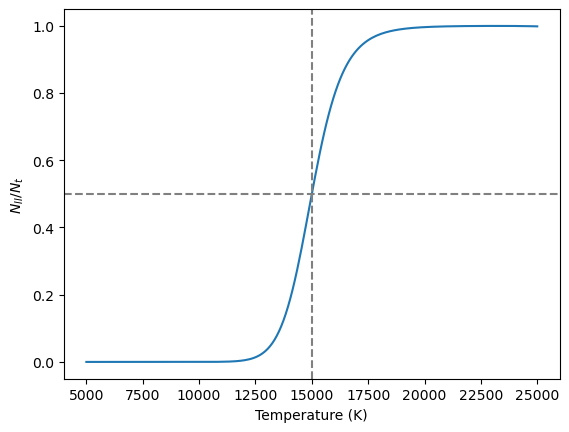

In [15]:
# c) graph N_II/N_t for a range of temperatures

T = np.linspace(5000, 25000, 200)*u.K
N2_N1 = saha(0, X, Z, P_e, T)
N3_N2 = saha(1, X, Z, P_e, T)

N2_Nt = N2_N1 / (1 + N2_N1 + N3_N2*N2_N1)
 
# find half-ionization point
half_ionization = np.interp(0.5, N2_Nt, T)
print('Half ionization point:', half_ionization)

plt.plot(T, N2_Nt)
plt.axhline(y=0.5, color='grey', linestyle='--') 
plt.axvline(x=half_ionization.value, color='grey', linestyle='--')  
plt.xlabel("Temperature (K)")
plt.ylabel("$N_{II}/N_t$")